<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Matter006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

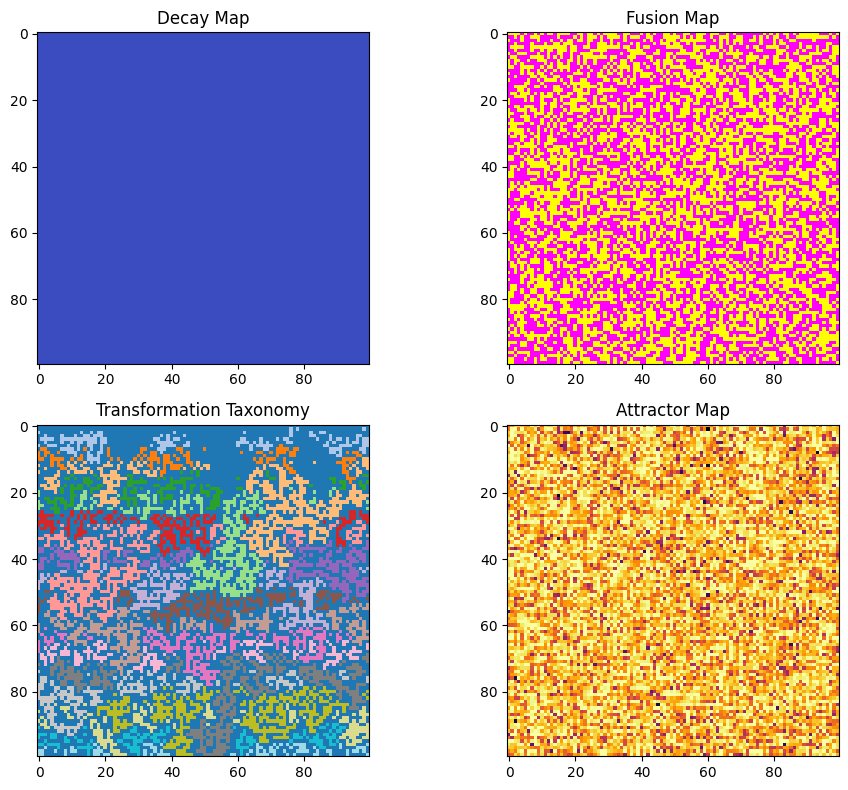

In [2]:
# 🧪 Matter006: Decay & Fusion – HES Lattice Simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# --- Simulation Parameters ---
N = 100
steps = 500
entropy_seed_strength = 0.1
curvature_threshold = 0.05
bonding_threshold = 0.6
fusion_threshold = 0.8
decay_curvature_limit = 4

# --- Initialize Lattice ---
S = np.random.rand(N, N) * entropy_seed_strength
curvature_memory = np.zeros_like(S)
attractor_map = np.zeros_like(S)

# --- Evolution Function ---
def evolve(S):
    grad_x, grad_y = np.gradient(S)
    laplacian = np.gradient(grad_x)[0] + np.gradient(grad_y)[1]
    return S - 0.01 * laplacian

# --- Simulation Loop ---
for t in range(steps):
    S = evolve(S)
    curvature = np.abs(np.gradient(np.gradient(S)[0])[0] + np.gradient(np.gradient(S)[1])[1])
    curvature_memory += curvature
    attractor_map += (curvature > curvature_threshold).astype(float)

# --- Polarity & Valence ---
polarity = np.random.choice([-1, 1], size=(N, N))
valence = np.clip(curvature_memory // 5, 1, 4)

# --- Coupling & Bonding ---
grad_x, grad_y = np.gradient(S)
entropy_flow_magnitude = np.sqrt(grad_x**2 + grad_y**2)
coupling_strength = entropy_flow_magnitude * curvature_memory
bonding_map = (coupling_strength > bonding_threshold) & (polarity == -1)

# --- Shell Formation ---
shell_map, num_shells = label(bonding_map.astype(float))

# --- Decay Map ---
decay_map = np.zeros_like(S)
decay_map[(bonding_map) & (curvature_memory < decay_curvature_limit)] = 1

# --- Fusion Map ---
fusion_map = np.zeros_like(S)
fusion_map[(bonding_map) & (coupling_strength > fusion_threshold)] = 1

# --- Elemental Transformation Taxonomy ---
transformation_map = shell_map + 2 * decay_map + 3 * fusion_map

# --- Visualization ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(decay_map, cmap='coolwarm'); axs[0, 0].set_title("Decay Map")
axs[0, 1].imshow(fusion_map, cmap='spring'); axs[0, 1].set_title("Fusion Map")
axs[1, 0].imshow(transformation_map, cmap='tab20'); axs[1, 0].set_title("Transformation Taxonomy")
axs[1, 1].imshow(attractor_map, cmap='inferno'); axs[1, 1].set_title("Attractor Map")
plt.tight_layout(); plt.show()
